## Building a sarcasm dataset classifier

In [33]:
# Import libraries
import io
import os
import zipfile
import numpy as np

import tensorflow as tf
import json
import tensorflow_datasets as tfds
from tensorflow.keras.utils import pad_sequences
import matplotlib.pyplot as plt

In [2]:
!kaggle datasets download rmisra/news-headlines-dataset-for-sarcasm-detection

Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection
License(s): Attribution 4.0 International (CC BY 4.0)
news-headlines-dataset-for-sarcasm-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
filepath = os.path.join(os.getcwd(), "Data/news-headlines-dataset-for-sarcasm-detection.zip")

with zipfile.ZipFile(filepath, 'r') as zipref:
    zipref.extractall("Data/")

In [4]:
# Load the data from json file
json_filepath = os.path.join(os.getcwd(), "Data/Sarcasm_Headlines_Dataset.json")
datastore = [json.loads(line) for line in open(json_filepath, 'r')]

print(f"Sample data points -\n{datastore[0]}\n\n{datastore[1]}")

Sample data points -
{'article_link': 'https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5', 'headline': "former versace store clerk sues over secret 'black code' for minority shoppers", 'is_sarcastic': 0}

{'article_link': 'https://www.huffingtonpost.com/entry/roseanne-revival-review_us_5ab3a497e4b054d118e04365', 'headline': "the 'roseanne' revival catches up to our thorny political mood, for better and worse", 'is_sarcastic': 0}


### Getting and pre-processing sentences

    1. Use the TextVectorization layer for creating the vocabulary
    2. Create post-padded sequences
    3. Create pre-padded sequences

In [5]:
# Fetch the sentences (headlines)
sentences = [datapoint['headline'] for datapoint in datastore]

sentences[1]

"the 'roseanne' revival catches up to our thorny political mood, for better and worse"

#### Spliting the dataset into sentences and labels

In [6]:
sentences = []
labels = []

for item in datastore:
    sentences.append(item['headline'])
    labels.append(item['is_sarcastic'])

#### Parameters

In [7]:
# Max examples in the training set
TRAINING_SIZE = 20000
# Max tokens in the vocabulary
VOCAB_SIZE = 10000
# Max length of the padded sequences
MAX_LENGTH = 32
# Output dimensions of embedding layer
EMBEDDING_DIMS = 16

### Split the dataset

In [9]:
training_sentences = sentences[:TRAINING_SIZE]
test_sentences = sentences[TRAINING_SIZE:]

training_labels = labels[:TRAINING_SIZE]
test_labels = labels[TRAINING_SIZE:]

### Preprocess the train and test datasets
    1. Tokenize & Vectorize the datasets
    2. Cache, shuffle and prefetch the vectorized datasets

In [10]:
# Define the vectorization layer
vectorize_layer = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LENGTH)

# Generate the vocabulary
vectorize_layer.adapt(training_sentences)

2025-07-07 22:03:31.037231: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-07-07 22:03:31.037399: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-07-07 22:03:31.037404: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1751906011.037429 20955820 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1751906011.037500 20955820 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
# Create tokens and assign numerical representations
train_sequences = vectorize_layer(training_sentences)
test_sequences = vectorize_layer(test_sentences)

#### Combine the sentences and labels into a `tf.data.Dataset`

In [13]:
training_dataset = tf.data.Dataset.from_tensor_slices((train_sequences, training_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_sequences, test_labels))

In [15]:
# Checkout some examples
for example in training_dataset.take(2):
    print(example)

(<tf.Tensor: shape=(32,), dtype=int64, numpy=
array([ 319,    1,  943, 4079, 2366,   47,  366,   94, 2026,    6, 2653,
       9470,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0])>, <tf.Tensor: shape=(), dtype=int32, numpy=0>)
(<tf.Tensor: shape=(32,), dtype=int64, numpy=
array([   4, 7185, 3128, 3305,   28,    2,  152,    1,  358, 2902,    6,
        236,    9,  844,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0])>, <tf.Tensor: shape=(), dtype=int32, numpy=0>)


2025-07-07 22:09:31.538039: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# Optimize the datasets for training
training_dataset_final = (training_dataset
                       .cache()
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .prefetch(PREFETCH_BUFFER_SIZE)
                       .batch(BATCH_SIZE)
                       )

test_dataset_final = (test_dataset
                      .cache()
                      .prefetch(PREFETCH_BUFFER_SIZE)
                      .batch(BATCH_SIZE)
                      )

### Build and compile model

    I would be using the GlobalAveragePooling1D layer instead of the Flatten layer

In [23]:
# Understanding how the GlobalAveragePooling layer works
gpoollayer = tf.keras.layers.GlobalAveragePooling1D()
sample_array = np.array([[[10,2,5],[1,3,3],[1,1,3]]])
output = gpoollayer(sample_array)

print(f"Sample input:\n {sample_array}")
print(f"Global Average Pooling layer output: {output}")

Sample input:
 [[[10  2  5]
  [ 1  3  3]
  [ 1  1  3]]]
Global Average Pooling layer output: [[4.        2.        3.6666667]]


#### Embeddings & Tensorflow enbedding layer

    - Embeddings are vectors that are used to represent words in a lower dimensional space so that these vectors can be fed to the neural networks.
    - Embedding layer transforms words or IDs into vectors which are easier to feed into the neural networks

In [24]:
# Build the model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(MAX_LENGTH, )),
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIMS),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 32, 16)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,433 (626.69 KB)

 Trainable params: 160,433 (626.69 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Compile the model
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

### Training and result visualization

In [26]:
# Train the model
num_epochs = 10

# Train the model
history = model.fit(training_dataset_final, 
                    epochs=num_epochs, 
                    validation_data=test_dataset_final)

Epoch 1/10


2025-07-07 22:30:06.351579: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5948 - loss: 0.6541 - val_accuracy: 0.8146 - val_loss: 0.4377
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8350 - loss: 0.3957 - val_accuracy: 0.8447 - val_loss: 0.3694
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8781 - loss: 0.3044 - val_accuracy: 0.8498 - val_loss: 0.3516
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9014 - loss: 0.2488 - val_accuracy: 0.8493 - val_loss: 0.3603
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9210 - loss: 0.2112 - val_accuracy: 0.8511 - val_loss: 0.3647
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9309 - loss: 0.1843 - val_accuracy: 0.8484 - val_loss: 0.3840
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9417 - loss: 0.1604 - val_accuracy: 0.8360 - val_loss: 0.4286
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9466 - loss: 0.1499 - val_accuracy: 

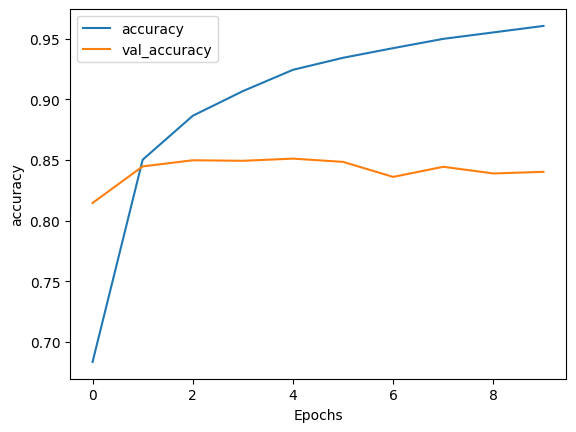

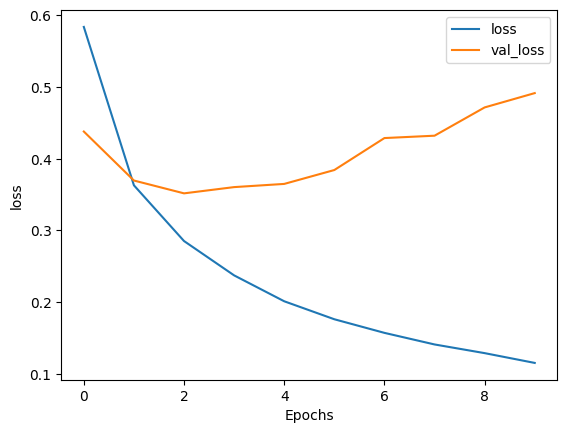

In [30]:
# Visualizing the results
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

# Plot the accuracy and loss
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

### Visualize the embeddings

  
  Visualize the final weights of the embeddings using the [Tensorflow Embedding Projector](https://projector.tensorflow.org/).

In [31]:
# Get the embedding layer from the model (i.e. first layer)
embedding_layer = model.layers[0]

# Get the weights of the embedding layer
embedding_weights = embedding_layer.get_weights()[0]

# Print the shape. Expected is (vocab_size, embedding_dim)
print(embedding_weights.shape)

(10000, 16)


In [34]:
# Open writeable files
out_v = io.open('vecs.tsv', 'w', encoding='utf-8')
out_m = io.open('meta.tsv', 'w', encoding='utf-8')

# Get the word list
vocabulary = vectorize_layer.get_vocabulary()

# Initialize the loop. Start counting at `1` because `0` is just for the padding
for word_num in range(1, len(vocabulary)):

  # Get the word associated with the current index
  word_name = vocabulary[word_num]

  # Get the embedding weights associated with the current index
  word_embedding = embedding_weights[word_num]

  # Write the word name
  out_m.write(word_name + "\n")

  # Write the word embedding
  out_v.write('\t'.join([str(x) for x in word_embedding]) + "\n")

# Close the files
out_v.close()
out_m.close()

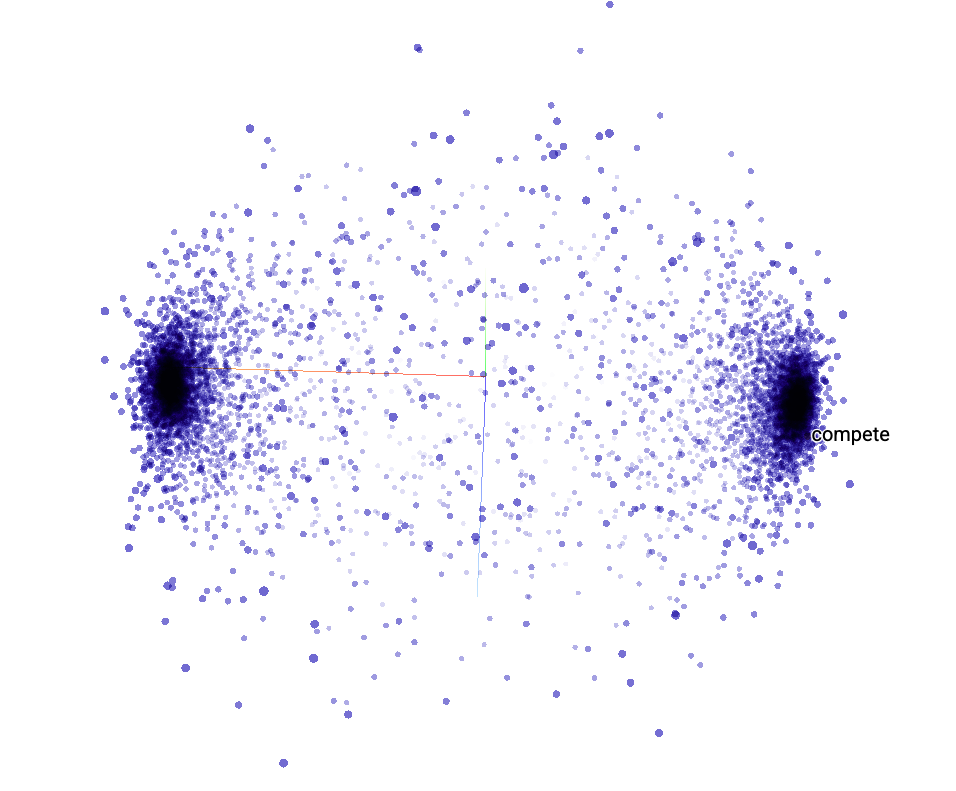